# Retained model — sparse logistic classification

The retained model predicts the probability of a positive target directly. All
learned preprocessing is contained in a scikit-learn pipeline and fitted again
inside every validation fold.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "src").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.cross_validation import CVConfig, ModelConfig, run_cv
from src.data import ChallengeDataLoader
from src.models import MODEL_FEATURES, make_baseline_v2

X_train = ChallengeDataLoader.load_X_train()
y_train = ChallengeDataLoader.load_y_train()
X_test = ChallengeDataLoader.load_X_test()

## 1. Model specification

The pipeline contains:

1. median imputation and standardisation for selected lagged returns;
2. one-hot fixed effects for `ALLOCATION` and `GROUP`;
3. allocation-specific `RET_1` slopes;
4. an L2-regularised logistic regression with `C=0.003`.

It does not use date order, target encoding or reconstructed rolling windows.

In [2]:
pipeline = make_baseline_v2()
pipeline

Pipeline(steps=[('design', FixedEffectDesign()),
                ('classifier',
                 LogisticRegression(C=0.003, max_iter=150, random_state=0,
                                    tol=1e-05))])

## 2. Date-grouped validation

In [3]:
cv_result = run_cv(
    X_train,
    y_train,
    ModelConfig(model=pipeline, features=list(MODEL_FEATURES)),
    CVConfig(n_splits=8, shuffle=True, random_state=0),
)

date_summary = cv_result.score_summary(grouper="TS")
fold_rows = [
    {
        "fold": fold.fold_id,
        "validation rows": int(fold.valid_index.sum()),
        "accuracy": fold.valid_metrics["accuracy"],
        "balanced accuracy": fold.valid_metrics["balanced_accuracy"],
        "prediction positive rate": fold.valid_metrics["prediction_positive_rate"],
    }
    for fold in cv_result.fold_results
]
fold_metrics = pd.DataFrame(fold_rows)

pd.Series(
    {
        "OOF accuracy": cv_result.mean_accuracy,
        "date-clustered standard error": date_summary["standard_error"],
        "date-penalized score": date_summary["penalized_score"],
        "OOF rows": len(cv_result.oof_results),
        "dates": date_summary["n_groups"],
    }
).to_frame("value")

,value
OOF accuracy,0.525001
date-clustered standard error,0.001716
date-penalized score,0.523285
OOF rows,527073.000000
dates,2522.000000


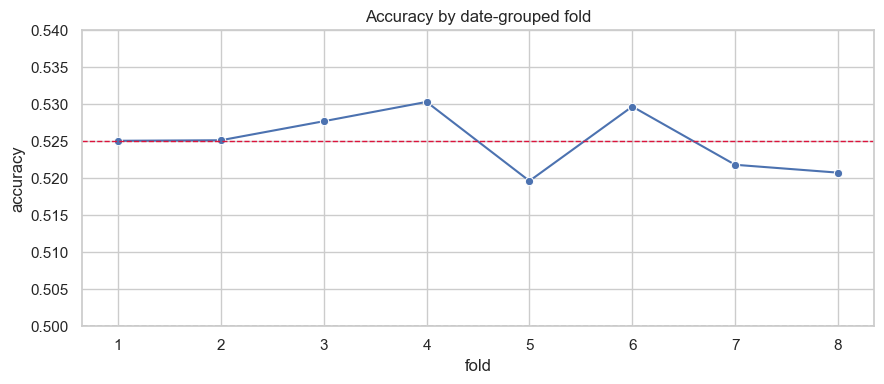

,fold,validation rows,accuracy,balanced accuracy,prediction positive rate
0,1,65998,0.525077,0.523117,0.599609
1,2,66349,0.525147,0.523034,0.609881
2,3,64972,0.527720,0.525146,0.584806
3,4,64565,0.530334,0.528894,0.607109
4,5,67413,0.519648,0.518431,0.608280
5,6,66229,0.529708,0.528173,0.616543
6,7,66209,0.521832,0.521077,0.602486
7,8,65338,0.520769,0.520762,0.619257


In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(data=fold_metrics, x="fold", y="accuracy", marker="o", ax=ax)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
ax.axhline(cv_result.mean_accuracy, color="crimson", linestyle="--", linewidth=1)
ax.set_title("Accuracy by date-grouped fold")
ax.set_ylim(0.50, max(0.54, fold_metrics["accuracy"].max() + 0.005))
plt.tight_layout()
plt.show()
fold_metrics

## 3. Stability across dates and allocations

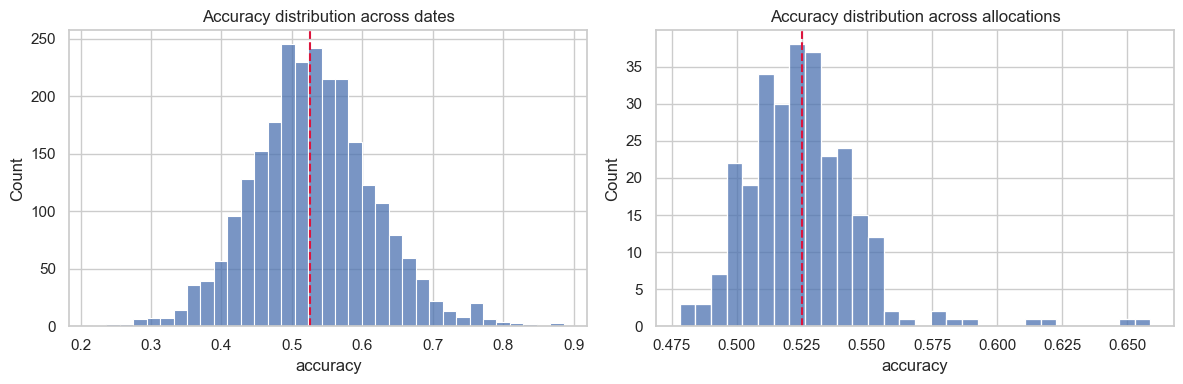

,level,groups,unweighted mean accuracy,accuracy standard deviation
0,date,2522,0.530185,0.086171
1,allocation,278,0.525110,0.022551


In [5]:
oof = cv_result.oof_results
stability_date = oof.groupby("TS")["is_correct"].agg(["size", "mean"]).rename(
    columns={"size": "rows", "mean": "accuracy"}
)
stability_allocation = oof.groupby("ALLOCATION")["is_correct"].agg(["size", "mean"]).rename(
    columns={"size": "rows", "mean": "accuracy"}
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(stability_date["accuracy"], bins=35, ax=axes[0])
axes[0].axvline(cv_result.mean_accuracy, color="crimson", linestyle="--")
axes[0].set_title("Accuracy distribution across dates")
sns.histplot(stability_allocation["accuracy"], bins=30, ax=axes[1])
axes[1].axvline(cv_result.mean_accuracy, color="crimson", linestyle="--")
axes[1].set_title("Accuracy distribution across allocations")
plt.tight_layout()
plt.show()

pd.DataFrame(
    {
        "level": ["date", "allocation"],
        "groups": [len(stability_date), len(stability_allocation)],
        "unweighted mean accuracy": [
            stability_date["accuracy"].mean(),
            stability_allocation["accuracy"].mean(),
        ],
        "accuracy standard deviation": [
            stability_date["accuracy"].std(),
            stability_allocation["accuracy"].std(),
        ],
    }
)

## 4. Feature contributions and submission checks

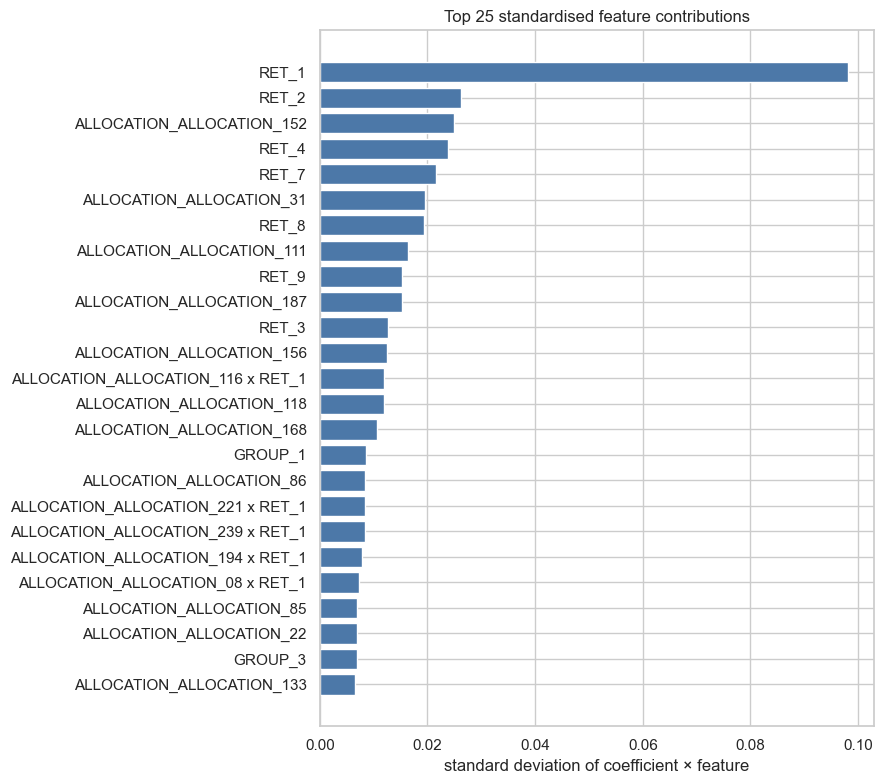

,feature,coefficient,contribution standard deviation
0,RET_1,0.098047,0.098047
1,RET_2,-0.026252,0.026252
75,ALLOCATION_ALLOCATION_152,0.366841,0.024897
3,RET_4,-0.023842,0.023842
4,RET_7,0.021533,0.021533
217,ALLOCATION_ALLOCATION_31,0.327981,0.019470
5,RET_8,0.019432,0.019432
30,ALLOCATION_ALLOCATION_111,-0.274405,0.016290
6,RET_9,0.015303,0.015303
113,ALLOCATION_ALLOCATION_187,0.252106,0.015231


In [6]:
fitted_pipeline = make_baseline_v2().fit(X_train, y_train["target_binarized"])
design = fitted_pipeline.named_steps["design"]
classifier = fitted_pipeline.named_steps["classifier"]
design_matrix = design.transform(X_train)

feature_mean = np.asarray(design_matrix.mean(axis=0)).ravel()
feature_second_moment = np.asarray(design_matrix.power(2).mean(axis=0)).ravel()
feature_std = np.sqrt(np.maximum(feature_second_moment - feature_mean**2, 0.0))
importance = pd.DataFrame(
    {
        "feature": design.get_feature_names_out(),
        "coefficient": classifier.coef_.ravel(),
        "contribution standard deviation": np.abs(classifier.coef_.ravel()) * feature_std,
    }
).sort_values("contribution standard deviation", ascending=False)

top = importance.head(25).sort_values("contribution standard deviation")
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top["feature"], top["contribution standard deviation"], color="#4C78A8")
ax.set_title("Top 25 standardised feature contributions")
ax.set_xlabel("standard deviation of coefficient × feature")
plt.tight_layout()
plt.show()
importance.head(15)

In [7]:
test_predictions = fitted_pipeline.predict(X_test)
pd.Series(
    {
        "test rows": len(test_predictions),
        "missing predictions": int(pd.isna(test_predictions).sum()),
        "prediction classes": sorted(np.unique(test_predictions).tolist()),
        "positive prediction rate": test_predictions.mean(),
    }
).to_frame("value")

,value
test rows,31870
missing predictions,0
prediction classes,"[0, 1]"
positive prediction rate,0.602259


## Reproduction

The canonical estimator is `src.models.make_baseline_v2`; grouped validation is
implemented by `src.cross_validation.run_cv`. The same complete pipeline is
cloned and fitted independently in every fold.